# This notebook is used to plot curvefit for the playfight data sess 1 and 2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from scipy.stats import ttest_rel,wilcoxon
path_to_add = os.path.abspath('../')
sys.path.append(path_to_add)
from func_fix_curvefit_params import *
import os

In [2]:
path_to_add = os.path.abspath('../')
path_to_add

'/Users/f0053cz/Dartmouth College Dropbox/Rekha Sreekumar Varrier/postdoc_Dartmouth/psyanim_behav_paper/version2/scripts_data_for_beh_paper/code'

In [3]:
sys.path.append(path_to_add)
from func_curvefit import *
import seaborn as sns

In [4]:
root_data_file = '../../data/playfight_data'

In [5]:
## import dataframes (curvefit)
df_params_test = pd.read_csv(f'{root_data_file}/curve_fit_aggressiveness_ses1_linear/all_params_1k_fight_linear.csv')
df_params_retest = pd.read_csv(f'{root_data_file}/curve_fit_aggressiveness_ses2_linear/all_params_1k_fight_linear.csv')
df_params_test.shape, df_params_retest.shape

((319, 12), (269, 12))

In [6]:
df_params_test = fix_obj_center(df_params_test)
df_params_retest = fix_obj_center(df_params_retest)

In [7]:
## merging the two curvefit params dataframe
df_params_merge = df_params_test.merge(df_params_retest, on = 'subID', suffixes = ('_ses1', '_ses2'))
df_params_merge

,subID,r_squared_ses1,nrmse_ses1,aic_ses1,obj_center_ses1,slope_ses1,intercept_ses1,bias_xmin_ses1,bias_xmax_ses1,bias_lower_ses1,...,nrmse_ses2,aic_ses2,obj_center_ses2,slope_ses2,intercept_ses2,bias_xmin_ses2,bias_xmax_ses2,bias_lower_ses2,bias_upper_ses2,flipped_ses2
0,26000.0,0.940328,0.089873,-35.484797,0.709516,0.704565,0.000100,0.000100,0.295335,0.0,...,0.114475,-39.241819,0.875295,0.477381,0.082151,0.082151,0.440468,0.0,0.0,False
1,26001.0,0.823224,0.147384,-35.444795,0.594001,0.386857,0.270206,0.270206,0.342937,0.0,...,0.140828,-30.664804,0.504384,0.521357,0.237036,0.237036,0.241607,0.0,0.0,False
2,26003.0,0.915302,0.111619,-26.697277,0.499900,1.000000,0.000100,0.000100,-0.000100,0.0,...,0.085179,-31.422912,0.481000,1.000000,0.019000,0.019000,-0.019000,0.0,0.0,False
3,26004.0,0.972040,0.051894,-43.866039,0.526637,0.579214,0.194964,0.194964,0.225821,0.0,...,0.130596,-45.074530,0.797405,0.214714,0.328786,0.328786,0.456500,0.0,0.0,False
4,26005.0,0.936739,0.089287,-38.116158,0.420301,0.570000,0.260429,0.260429,0.169571,0.0,...,0.063656,-37.695388,0.622282,0.803334,0.000100,0.000100,0.196566,0.0,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,26343.0,0.881986,0.130820,-32.029021,0.601861,0.625500,0.123536,0.123536,0.250964,0.0,...,0.080978,-35.254970,0.572666,0.676286,0.112714,0.112714,0.211000,0.0,0.0,False
258,26344.0,0.849478,0.155297,-23.720998,0.606647,0.824037,0.000100,0.000100,0.175863,0.0,...,0.107550,-30.029643,0.630982,0.792257,0.000100,0.000100,0.207643,0.0,0.0,False
259,26346.0,0.855388,0.122336,-30.751435,0.511248,0.609643,0.188321,0.188321,0.202036,0.0,...,0.083382,-39.407191,0.453082,0.523714,0.262714,0.262714,0.213571,0.0,0.0,False
260,26347.0,0.852070,0.125535,-43.857648,0.824250,0.235905,0.305556,0.305556,0.458540,0.0,...,0.085602,-47.646641,0.726680,0.282476,0.294730,0.294730,0.422794,0.0,0.0,False


In [8]:
df_params_merge.loc[np.isnan(df_params_merge['obj_center_ses1']),:]

,subID,r_squared_ses1,nrmse_ses1,aic_ses1,obj_center_ses1,slope_ses1,intercept_ses1,bias_xmin_ses1,bias_xmax_ses1,bias_lower_ses1,...,nrmse_ses2,aic_ses2,obj_center_ses2,slope_ses2,intercept_ses2,bias_xmin_ses2,bias_xmax_ses2,bias_lower_ses2,bias_upper_ses2,flipped_ses2
40,26060.0,0.079847,0.302446,-38.842548,NaN,0.041429,NaN,0.286857,0.754571,1.0,...,0.151992,-38.196440,1.000000,0.318643,0.153393,0.153393,0.527964,0.0,0.0,False
140,26193.0,0.942874,0.083005,-30.885994,NaN,0.962103,NaN,0.962203,0.999900,1.0,...,0.133840,-27.144130,NaN,0.791238,NaN,0.877714,0.913524,1.0,1.0,True
143,26198.0,0.282172,0.280972,-39.169052,NaN,0.086143,NaN,0.594452,0.491690,1.0,...,0.202644,-36.575635,0.645241,0.204750,0.367887,0.367887,0.427363,0.0,0.0,False
185,26253.0,0.539145,0.254507,-36.419557,NaN,0.180857,NaN,0.619571,0.561286,1.0,...,0.251354,-30.957860,0.982058,0.169643,0.333401,0.333401,0.496956,0.0,0.0,False
212,26285.0,0.021571,0.348544,-42.059395,NaN,0.016595,NaN,0.494980,0.521615,1.0,...,0.233202,-42.135603,1.000000,0.085952,0.412167,0.412167,0.501881,0.0,0.0,False
252,26338.0,0.549116,0.228676,-37.415560,NaN,0.171857,NaN,0.243357,0.928500,1.0,...,0.318760,-31.247547,1.000000,0.059786,0.361964,0.361964,0.578250,0.0,0.0,False


In [9]:
## import raw dataframes (rating)
df_data_test = pd.read_csv(f'{root_data_file}/final_data_triallevel_sorted_ses1.csv')
df_data_retest = pd.read_csv(f'{root_data_file}/final_data_triallevel_sorted_ses2.csv')
df_params_test.shape, df_params_retest.shape

((319, 12), (269, 12))

In [10]:
print('before:',df_params_merge.shape)
df_params_merge.dropna(inplace=True)
df_params_merge.shape

before: (262, 23)


(252, 23)

In [14]:
df_params_merge.loc[df_params_merge.slope_ses1<0,:], df_params_merge.loc[df_params_merge.slope_ses2<0,:]

(Empty DataFrame
 Columns: [subID, r_squared_ses1, nrmse_ses1, aic_ses1, obj_center_ses1, slope_ses1, intercept_ses1, bias_xmin_ses1, bias_xmax_ses1, bias_lower_ses1, bias_upper_ses1, flipped_ses1, r_squared_ses2, nrmse_ses2, aic_ses2, obj_center_ses2, slope_ses2, intercept_ses2, bias_xmin_ses2, bias_xmax_ses2, bias_lower_ses2, bias_upper_ses2, flipped_ses2]
 Index: []
 
 [0 rows x 23 columns],
 Empty DataFrame
 Columns: [subID, r_squared_ses1, nrmse_ses1, aic_ses1, obj_center_ses1, slope_ses1, intercept_ses1, bias_xmin_ses1, bias_xmax_ses1, bias_lower_ses1, bias_upper_ses1, flipped_ses1, r_squared_ses2, nrmse_ses2, aic_ses2, obj_center_ses2, slope_ses2, intercept_ses2, bias_xmin_ses2, bias_xmax_ses2, bias_lower_ses2, bias_upper_ses2, flipped_ses2]
 Index: []
 
 [0 rows x 23 columns])

- at ths stage, neg bias_xmax isn't a huge deal bc we're not using the params by themselves for an ICC-like analysis (plus they are really small values close to 0)

## Plotting all results: curves & ratings from ses 1 and ses 2

In [23]:
rootfile_results = '../../results/playfight/refit_across_sessions_fight'

In [24]:
# filter behavioral scores
df_data_ses1 = df_data_test.loc[:, df_data_test.columns != 'stim_file']
df_data_ses2 = df_data_retest.loc[:, df_data_retest.columns != 'stim_file']

## preprocess the dataframe
df_data_ses1 = df_data_test.loc[:, df_data_test.columns != 'stim_file']
df_data_ses1 = df_data_ses1.groupby(['subID','chargeSpeeds']).mean().reset_index()

df_data_ses2 = df_data_retest.loc[:, df_data_retest.columns != 'stim_file']
df_data_ses2 = df_data_ses2.groupby(['subID','chargeSpeeds']).mean().reset_index()

In [25]:
## merging the two rating df 
df_rating_merge = df_data_ses1.merge(df_data_ses2, on=['subID', 'chargeSpeeds'], suffixes = ('_ses1', '_ses2'))
df_rating_merge.head()

,subID,chargeSpeeds,Unnamed: 0_ses1,stimset_rows_ses1,stim_dur_ses1,responses_ses1,RT_ses1,trial_num_ses1,Unnamed: 0_ses2,stimset_rows_ses2,stim_dur_ses2,responses_ses2,RT_ses2,trial_num_ses2
0,26000,1.50,30.9,266.0,7718.3,3.5,2.061,30.9,36.6,NaN,7944.6,13.100000,2.470000,36.6
1,26000,2.75,25.9,266.0,7716.7,11.1,1.768,25.9,23.7,NaN,7948.5,13.333333,2.392222,23.7
2,26000,4.00,30.8,266.0,7716.3,25.8,1.914,30.8,24.6,NaN,7937.2,15.555556,3.117778,24.6
3,26000,5.25,41.1,266.0,7693.9,22.8,2.018,41.1,32.5,NaN,7942.2,35.300000,2.474000,32.5
4,26000,6.50,34.3,266.0,7700.8,45.6,1.680,34.3,41.7,NaN,7912.9,43.200000,2.162000,41.7


In [26]:
df_rating_merge = df_rating_merge.loc[df_rating_merge['subID'].isin(df_params_merge['subID']),:]
df_rating_merge

,subID,chargeSpeeds,Unnamed: 0_ses1,stimset_rows_ses1,stim_dur_ses1,responses_ses1,RT_ses1,trial_num_ses1,Unnamed: 0_ses2,stimset_rows_ses2,stim_dur_ses2,responses_ses2,RT_ses2,trial_num_ses2
0,26000,1.50,30.9,266.0,7718.3,3.500000,2.061000,30.9,36.6,NaN,7944.6,13.100000,2.470000,36.6
1,26000,2.75,25.9,266.0,7716.7,11.100000,1.768000,25.9,23.7,NaN,7948.5,13.333333,2.392222,23.7
2,26000,4.00,30.8,266.0,7716.3,25.800000,1.914000,30.8,24.6,NaN,7937.2,15.555556,3.117778,24.6
3,26000,5.25,41.1,266.0,7693.9,22.800000,2.018000,41.1,32.5,NaN,7942.2,35.300000,2.474000,32.5
4,26000,6.50,34.3,266.0,7700.8,45.600000,1.680000,34.3,41.7,NaN,7912.9,43.200000,2.162000,41.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1829,26348,4.00,34.7,245.0,8004.3,45.900000,2.042000,34.7,31.9,NaN,7988.8,21.100000,2.307000,31.9
1830,26348,5.25,41.4,245.0,9104.3,67.111111,2.977778,41.4,29.6,NaN,7995.3,53.500000,2.922000,29.6
1831,26348,6.50,25.8,245.0,7973.4,51.400000,1.895000,25.8,48.5,NaN,7964.9,41.000000,2.076000,48.5
1832,26348,7.75,42.4,245.0,7841.4,72.900000,2.677000,42.4,32.1,NaN,7963.8,80.400000,2.334000,32.1


In [27]:
len(np.unique(df_rating_merge['subID']))

252

## Fitting own data from one session to another

In [28]:
s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

In [29]:
df_rating_merge

,subID,chargeSpeeds,Unnamed: 0_ses1,stimset_rows_ses1,stim_dur_ses1,responses_ses1,RT_ses1,trial_num_ses1,Unnamed: 0_ses2,stimset_rows_ses2,stim_dur_ses2,responses_ses2,RT_ses2,trial_num_ses2
0,26000,1.50,30.9,266.0,7718.3,3.500000,2.061000,30.9,36.6,NaN,7944.6,13.100000,2.470000,36.6
1,26000,2.75,25.9,266.0,7716.7,11.100000,1.768000,25.9,23.7,NaN,7948.5,13.333333,2.392222,23.7
2,26000,4.00,30.8,266.0,7716.3,25.800000,1.914000,30.8,24.6,NaN,7937.2,15.555556,3.117778,24.6
3,26000,5.25,41.1,266.0,7693.9,22.800000,2.018000,41.1,32.5,NaN,7942.2,35.300000,2.474000,32.5
4,26000,6.50,34.3,266.0,7700.8,45.600000,1.680000,34.3,41.7,NaN,7912.9,43.200000,2.162000,41.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1829,26348,4.00,34.7,245.0,8004.3,45.900000,2.042000,34.7,31.9,NaN,7988.8,21.100000,2.307000,31.9
1830,26348,5.25,41.4,245.0,9104.3,67.111111,2.977778,41.4,29.6,NaN,7995.3,53.500000,2.922000,29.6
1831,26348,6.50,25.8,245.0,7973.4,51.400000,1.895000,25.8,48.5,NaN,7964.9,41.000000,2.076000,48.5
1832,26348,7.75,42.4,245.0,7841.4,72.900000,2.677000,42.4,32.1,NaN,7963.8,80.400000,2.334000,32.1


In [30]:
# function that plots refit graph for self
def plot_refit_curvefit_self(nrows, ncols, df_params, df_rating, param_ses, rating_ses, flname,title):#, r2_list, rmse_list):
    # arguments: 
    # nrow,ncol - nr of rows and columns in the plot
    # df_params, df_rating: curve fit param and raw data dataframes
    # param_ses: train session, rating_ses: test ses
    # flname: full filename to save results in
    # ((not there anymore: r2_list, rmse_list - empty lists to store r1 and rmse in))
    # ((returning: nothing. the r2 and rmse lists update outside the function automatically))
    # returning: dataframe with subID, r2 and rmse

    r2_list = []
    rmse_list = []
    subID_all = []
    fig,axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*2,nrows*2.1), sharey=True,sharex=True)#(20, 70))
    
    # for isub in range(350):
    for isub,subID in enumerate(df_params_merge['subID']):
        # print(isub,subID)
        # ax = plt.subplot(nrows, ncols, isub)
        r = int(np.floor(isub/ncols))
        c = isub%ncols
        ax = axs[r,c]
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)

        # subID =  isub+1

        if isub%50 == 0:
            print('subID=',subID)

        # try:
        # behavior
        # xfit = 1-(df_rating.loc[df_rating['subID'] ==subID, 'chargeSpeeds'].values-1.5) / 7.5
        xfit = (df_rating.loc[df_rating['subID'] ==subID, 'chargeSpeeds'].values-1.5) / 7.5
        yfit = df_rating.loc[df_rating['subID'] == subID, f'responses_ses{rating_ses}'].values/100 #for playfulness
        #(100-df_rating.loc[df_rating['subID'] == subID, f'responses_ses{rating_ses}'].values)/100 #for playfulness
        
        # print(xfit)
        x = np.array(xfit)
        y = np.array(yfit)

        # print(xfit,yfit)

        # Plot behavioral dots
        ax.plot(x, y, '.', alpha=0.5, color='black')

        intercept = df_params_merge.loc[df_params_merge['subID'] == subID, f'intercept_ses{param_ses}'].values #f'bias_xmin_ses{param_ses}'].values
        slope = df_params_merge.loc[df_params_merge['subID'] == subID, f'slope_ses{param_ses}'].values #f'bias_xmin_ses{param_ses}'].values
        x_values = np.linspace(np.nanmin(x), np.nanmax(x), 100)
        y_values = linear(x_values, slope, intercept)

        # Plot the curves
        ax.plot(x_values, y_values, '-', color='tab:red')

        # Calculate the r_squared and rmse
        y_pred = linear(x, slope, intercept) #intercept + amplitude * sigmoid(x, sigma, center)
        r_sq = r_squared(y, y_pred)
        rmse = normalized_error(y, y_pred)

        r2_list.append(r_sq)
        rmse_list.append(rmse)
        subID_all.append(subID)

        if rmse <= 0.2:
            color = 'k'
        else:
            color = 'r'
        ax.set_title(f'Subject {subID}')
        ax.annotate("r_2: %.2f" % r_sq, xy=(1, 0.2), xycoords ='axes fraction', color=color,ha='right')
        ax.annotate("rmse: %.2f" % rmse, xy=(1, 0), xycoords ='axes fraction', color=color,ha='right')

        # except:
        #     print('isub, error!')
        #     plt.delaxes(ax)  
        #     r2_list.append(np.nan) # to keep list the same length as df
        #     rmse_list.append(np.nan)
        #     subID_all.append(subID)      
        
        ax.set_xticks([0,1],['9','1.5'])

    for isub in np.arange(df_params_merge.shape[0],nrows*ncols):
        ax =  plt.subplot(nrows, ncols, isub + 1)
        plt.delaxes(ax)  

    plt.suptitle(title, fontweight='bold',fontsize=24)
    plt.tight_layout() 
    plt.subplots_adjust(wspace=0.5, hspace=0.5) 
    plt.savefig(flname, facecolor='w')
    plt.clf()
    
    df = pd.DataFrame({'subID':subID_all,'R2':r2_list, 'RMSE': rmse_list})
    
    return df

In [31]:
df_params_merge.shape

(252, 23)

In [35]:
df_params_merge.dropna(inplace=True)
df_params_merge.shape

(252, 23)

In [36]:
nrows, ncols = 14, 20

In [37]:
load_data = 1 # enter 0 to not load (and compute params) and 1 to load csv

In [43]:
# Fitting ses 1 (curvefit param) to ses 1 (behavioral rating)
# self_r_sqaure_ses1_t_ses1 = []
# self_rmse_ses1_t_ses1 = []
if load_data:
    self_fit_ses1= pd.read_csv('../../data/playfight_data/refit/self_fit_ses1.csv')
else:
    title = 'ses1_to_ses1'
    flname = f'{rootfile_results}/sublevel/{title}_sublevel.png'
    self_fit_ses1 = plot_refit_curvefit_self(nrows, ncols, df_params_merge, df_rating_merge,
                        1, 1,flname,title)#, self_r_sqaure_ses1_t_ses1, self_rmse_ses1_t_ses1)
    self_fit_ses1.to_csv('../../data/playfight_data/refit/self_fit_ses1.csv')
self_fit_ses1.head()

,Unnamed: 0,subID,R2,RMSE
0,0,26000.0,0.940328,0.089873
1,1,26001.0,0.823224,0.147384
2,2,26003.0,0.915302,0.111619
3,3,26004.0,0.972040,0.051894
4,4,26005.0,0.936739,0.089287


In [44]:
# Fitting ses 2  (curvefit param) to ses 2 (behavioral rating)
# self_r_sqaure_ses2_t_ses2 = []
# self_rmse_ses2_t_ses2 = []
if load_data:
    self_fit_ses2= pd.read_csv('../../data/playfight_data/refit/self_fit_ses2.csv')
else:
    title = 'ses2_to_ses2' 
    flname = f'{rootfile_results}/sublevel/{title}_sublevel.png'
    self_fit_ses2 = plot_refit_curvefit_self(nrows, ncols, df_params_merge, df_rating_merge,
                        2, 2, flname,title) #self_r_sqaure_ses2_t_ses2, self_rmse_ses2_t_ses2)
    self_fit_ses2.to_csv('../../data/playfight_data/refit/self_fit_ses2.csv')
self_fit_ses2.head()

,Unnamed: 0,subID,R2,RMSE
0,0,26000.0,0.924233,0.114475
1,1,26001.0,0.810345,0.140828
2,2,26003.0,0.949312,0.085179
3,3,26004.0,0.850246,0.130596
4,4,26005.0,0.972524,0.063656


In [45]:
# Fitting ses 1 (curvefit param) to ses 2 (behavioral rating)
# self_r_sqaure_ses1_t_ses2 = []
# self_rmse_ses1_t_ses2 = []
if load_data:
    cross_fit_ses1to2= pd.read_csv('../../data/playfight_data/refit/cross_fit_ses1to2.csv')
else:
    title = 'ses1_to_ses2' 
    flname = f'{rootfile_results}/sublevel/{title}_sublevel.png'
    cross_fit_ses1to2 = plot_refit_curvefit_self(nrows, ncols, df_params_merge, df_rating_merge,
                        1, 2,flname,title) #, self_r_sqaure_ses1_t_ses2, self_rmse_ses1_t_ses2)
    cross_fit_ses1to2.to_csv('../../data/playfight_data/refit/cross_fit_ses1to2.csv')
cross_fit_ses1to2.head()

,Unnamed: 0,subID,R2,RMSE
0,0,26000.0,0.714915,0.235771
1,1,26001.0,0.756413,0.169501
2,2,26003.0,0.949312,0.087545
3,3,26004.0,-1.600045,0.583481
4,4,26005.0,0.861711,0.240853


In [46]:
# Fitting ses 2 (curvefit param) to ses 1 (behavioral rating)
# self_r_sqaure_ses2_t_ses1 = []
# self_rmse_ses2_t_ses1 = []
if load_data:
    cross_fit_ses2to1= pd.read_csv('../../data/playfight_data/refit/cross_fit_ses2to1.csv')
else:
    title = 'ses2_to_ses1'
    flname = f'{rootfile_results}/sublevel/{title}_sublevel.png'
    cross_fit_ses2to1 = plot_refit_curvefit_self(nrows, ncols, df_params_merge, df_rating_merge,
                        2, 1, flname,title)#, self_r_sqaure_ses2_t_ses1, self_rmse_ses2_t_ses1)
    cross_fit_ses2to1.to_csv('../../data/playfight_data/refit/cross_fit_ses2to1.csv')
cross_fit_ses2to1.head()

,Unnamed: 0,subID,R2,RMSE
0,0,26000.0,0.839723,0.154259
1,1,26001.0,0.723715,0.202521
2,2,26003.0,0.915302,0.115701
3,3,26004.0,0.587093,0.213681
4,4,26005.0,0.779766,0.308614


## Fitting mean of all other participants to self

In [47]:
## fit the mean to self
def plot_refit_curvefit_mean(nrows, ncols, df_params, df_rating, param_ses, rating_ses, flname, title):#, r2_list, rmse_list):
    # compares each sub's true data (test) to mean data from another session excluding that sub(train)
    
    # arguments: 
    # nrow,ncol - nr of rows and columns in the plot
    # df_params, df_rating: curve fit param and raw data dataframes
    # param_ses: train session, rating_ses: test ses
    # flname: full filename to save results in
    # ((not there anymore: r2_list, rmse_list - empty lists to store r1 and rmse in))
    # ((returning: nothing. the r2 and rmse lists update outside the function automatically))
    # returning: dataframe with subID, r2 and rmse

    subID_all = []
    r2_list = []
    rmse_list = []

    # plt.subplots(nrows=nrow, ncols=ncol, figsize=(20, 70))
    fig,axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*3.25,nrows*3), sharey=True,sharex=True)#(20, 70))
    
    for isub,subID in enumerate(df_params_merge['subID']):
    # for isub in range(350):
        r = int(np.floor(isub/ncols))
        c = isub%ncols
        ax = axs[r,c]
        # ax = plt.subplot(nrow, ncol, isub + 1)
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)

        if isub%50==0:
            print('subID=',subID)

        # try:
        # behavior
        # xfit = 1-(df_rating.loc[df_rating['subID'] ==subID, 'chargeSpeeds'].values-1.5) / 7.5
        xfit = (df_rating.loc[df_rating['subID'] ==subID, 'chargeSpeeds'].values-1.5) / 7.5
        yfit = df_rating.loc[df_rating['subID'] == subID, f'responses_ses{rating_ses}'].values/100 
        #(100-df_rating.loc[df_rating['subID'] == subID, f'responses_ses{rating_ses}'].values)/100 #for playfulness
         
        x = np.array(xfit)
        y = np.array(yfit)

        # Plot behavioral dots
        ax.plot(x, y, '.', alpha=0.5, color='black')

        df_temp = df_params_merge[df_params_merge['subID'] != subID].copy() # exclude current sub
        # other_mean: curve fit
        param_mean = df_temp.mean()

        intercept = param_mean[f'intercept_ses{param_ses}'] #df_params_merge.loc[df_params_merge['subID'] == subID, f'intercept_ses{param_ses}'].values #f'bias_xmin_ses{param_ses}'].values
        slope = param_mean[f'slope_ses{param_ses}'] #df_params_merge.loc[df_params_merge['subID'] == subID, f'slope_ses{param_ses}'].values #f'bias_xmin_ses{param_ses}'].values
        # intercept = param_mean[f'bias_xmin_ses{param_ses}']
        # center = param_mean[f'center_ses{param_ses}']
        # sigma = param_mean[f'sigma_ses{param_ses}']
        # bias_upper = param_mean[f'bias_xmax_ses{param_ses}']
        # amplitude = 1 - intercept - bias_upper
    
        x_values = np.linspace(np.nanmin(x), np.nanmax(x), 100)
        y_values = linear(x_values, slope, intercept)
        # Plot the curves
        ax.plot(x_values, y_values, '-', color='tab:red')

        # Calculate the r_squared and rmse
        y_pred = linear(x, slope, intercept) #intercept + amplitude * sigmoid(x, sigma, center)
        r_sq = r_squared(y, y_pred)
        rmse = normalized_error(y, y_pred)

        r2_list.append(r_sq)
        rmse_list.append(rmse)
        subID_all.append(subID)

        if rmse <= 0.2:
            color = 'k'
        else:
            color = 'r'

        ax.set_title(f'Subject {subID}')
        ax.annotate("r_2: %.2f" % r_sq, xy=(1, 0.2), xycoords ='axes fraction', color=color,ha='right')
        ax.annotate("rmse: %.2f" % rmse, xy=(1, 0), xycoords ='axes fraction', color=color,ha='right')

        # except:
        #     plt.delaxes(ax)  
        #     r2_list.append(np.nan) # to keep list the same length as df
        #     rmse_list.append(np.nan)

    ax.set_xticks([0,1],['180','0'])
    ax.set_yticks([0,0.5,1])
   
    for isub in np.arange(df_params_merge.shape[0],nrows*ncols):
        ax =  plt.subplot(nrows, ncols, isub + 1)
        plt.delaxes(ax)  

    plt.suptitle(title, fontweight='bold',fontsize=24)
    plt.tight_layout() 
    # plt.subplots_adjust(wspace=0.5, hspace=0.5) 
    plt.savefig(flname, facecolor='w')
    plt.clf()

    df = pd.DataFrame({'subID':subID_all,'R2':r2_list, 'RMSE': rmse_list})
    
    return df

In [48]:
rootfile_results

'../../results/playfight/refit_across_sessions_fight'

In [49]:
# fit mean to self: ses 1 mean (curvit) to ses 1 self(rating)
# mean_r_sqaure_ses1_t_ses1 = []
# mean_rmse_ses1_t_ses1 = []
if load_data:
    self_fit_mean_ses1= pd.read_csv('../../data/playfight_data/refit/self_fit_mean_ses1.csv')
else:
    title = 'ses1mean_to_ses1'
    flname = f'{rootfile_results}/mean/{title}_mean.png'
    self_fit_mean_ses1 = plot_refit_curvefit_mean(nrows, ncols, df_params_merge, df_rating_merge,
                        1, 1,flname,title)#, mean_r_sqaure_ses1_t_ses1, mean_rmse_ses1_t_ses1)
    self_fit_mean_ses1.to_csv('../../data/playfight_data/refit/self_fit_mean_ses1.csv')
self_fit_mean_ses1.head()

,Unnamed: 0,subID,R2,RMSE
0,0,26000.0,0.874226,0.196877
1,1,26001.0,0.721880,0.188547
2,2,26003.0,0.668141,0.221941
3,3,26004.0,0.962497,0.082925
4,4,26005.0,0.930058,0.199194


In [51]:
# fit mean to self: ses 2 mean (curvefit) to ses 2 self(rating)
# mean_r_sqaure_ses2_t_ses2 = []
# mean_rmse_ses2_t_ses2 = []
if load_data:
    self_fit_mean_ses2= pd.read_csv('../../data/playfight_data/refit/self_fit_mean_ses2.csv')
else:
    title = 'ses2mean_to_ses2'
    flname = f'{rootfile_results}/mean/{title}_mean.png'
    self_fit_mean_ses2 = plot_refit_curvefit_mean(nrows, ncols, df_params_merge, df_rating_merge,
                        2, 2,flname,title)#, mean_r_sqaure_ses2_t_ses2, mean_rmse_ses2_t_ses2)
    self_fit_mean_ses2.to_csv('../../data/playfight_data/refit/self_fit_mean_ses2.csv')
self_fit_mean_ses2.head()

,Unnamed: 0,subID,R2,RMSE
0,0,26000.0,0.901768,0.339620
1,1,26001.0,0.807612,0.167118
2,2,26003.0,0.741645,0.208007
3,3,26004.0,-1.258446,0.508686
4,4,26005.0,0.846093,0.161547


In [66]:
# Define a function to remove outliers based on 3*std deviation
def remove_outliers_std(df, columns):
    for col in columns:
        # print(df[col])
        mean = df[col].mean()
        std_dev = df[col].std()
        
        lower_bound = mean - 3 * std_dev
        upper_bound = mean + 3 * std_dev
        
        # Remove rows where column values are outliers
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    
    return df


In [166]:
def plot_pval(p):
    if p < .001:
        return '***'
    elif p < .01:
        return '**'
    elif p < .05:
        return '*'
    elif p < .1:
        return '$^{.}$'
    else:
        print('not significant')

In [172]:
def return_stats(x,y):
    t,p = ttest_rel(x,y)
    MD = (x-y).mean()
    return MD,t,p

def plot_rmse_dist_4_plots(self, self_altses, mean, flname, title,ylabel,ylims):
# def plot_rmse_dist_4_plots(self, self_altses, mean, mean_altses, flname, title,ylabel,ylims):
    # params = ['other_ind_mean', 'other_ind_median', 'other_ind_min']
    df_bootstrap = pd.DataFrame()
    df_bootstrap['self_sameses'] =[x for x in self if not np.isnan(x)]
    df_bootstrap['self_altses'] =[x for x in self_altses if not np.isnan(x)]
    df_bootstrap['mean_sameses'] = [x for x in mean if not np.isnan(x)]
    # df_bootstrap['mean_altses'] = [x for x in mean_altses if not np.isnan(x)]
    
    stats_array = np.full((3,3),np.nan) #MD,t,p
    count = -1
    all_grps = ['self_sameses', 'self_altses','mean_sameses']#,'mean_altses']

    for i,param1 in enumerate(all_grps[:-1]):
        for j,param2 in enumerate(all_grps[i+1:]):

            count += 1
            x = df_bootstrap[param1]
            y = df_bootstrap[param2]
            stats_array[count,:] = return_stats(x,y)
            print(f'{count}. param1:{param1},param2:{param2},MD:{stats_array[count,0]:.2f},t={stats_array[count,1]:.2f} ({get_p(stats_array[count,2])})')

    # for param in params: #  ['other_ind_mean', 'other_ind_median', 'other_ind_min']
    plt.figure(figsize=(5, 3))
    data_list = [df_bootstrap['self_sameses'], df_bootstrap['self_altses'], df_bootstrap['mean_sameses']]#, df_bootstrap['mean_altses']]
    positions = [0,1,2]#,3]    

    # Remove outliers
    data_list = remove_outliers_std(df_bootstrap, all_grps)

    parts = plt.violinplot(data_list, positions=positions, showmeans=True)
    # print(parts['bodies'])

    # Customize the body color
    for i,pc in enumerate(parts['bodies']):
        pc.set_facecolor('tab:red')
        pc.set_edgecolor('black')
        # else:
        # pc.set_edgecolor('tab:red')

        # if i in [0,2]:
        pc.set_linewidth(3)
        # if i == 2:
        #     parts['bodies'][i].set_hatch('//')

        pc.set_alpha(0.5)
        # if i == 1:
        #     pc.set_edgecolor('black')

    # Customize the mean line color
    parts['cmeans'].set_edgecolor('k')

    # Customize the minimum and maximum lines color
    parts['cmins'].set_edgecolor('k')
    parts['cmaxes'].set_edgecolor('k')

    # Change the color of the whiskers (vertical lines)
    for line in ['cbars', 'cmins', 'cmaxes']:
        if line in parts:
            parts[line].set_edgecolor('tab:red')
    
    plt.plot(data_list.T,color = 'grey',alpha=.1)

    lbls = ['12','13','23']
    p_values = []
    ypos = .95
    for i in range(stats_array.shape[0]):
        MD = stats_array[i,0]
        p = stats_array[i,2]
        txt = f'MD{lbls[i]}={MD:.2f}(t-test:{get_p(p)})'  #,\nwilc.:{get_p(p_wilc)})'
        ypos = ypos - .08
        p_values.append(p)
    
    plt.title(title, fontweight='bold')
    plt.xticks(positions, ['same\nparticipant,\nsame\nsession', 'same\nparticipant,\ndifferent\nsession', \
        "different\nparticipants,\nsame\nsession"],fontsize=14)#, "mean params\nfrom others\n(across sess;\ntest set)"])
    print(f'Self v mean:')
    plt.ylim(-.1,1.2)
    plt.xlim(-.5,2.5)

    plt.hlines(0.93,0,.9,color = 'k',linewidth = .5)
    plt.gca().annotate(plot_pval(p_values[0]), xy=(0.45,.93), color='k',ha='center')
    plt.hlines(0.93,1.1,2,color = 'k',linewidth = .5)
    plt.gca().annotate(plot_pval(p_values[2]), xy=(1.5, 0.93), color='k',ha='center')
    plt.hlines(1.1,0,2,color = 'k',linewidth = .5)
    plt.gca().annotate(plot_pval(p_values[1]), xy=(1, 1.08), color='k',ha='center')
    plt.ylabel(ylabel)
    plt.savefig(flname + '.png', bbox_inches='tight',dpi=300)
    # plt.clf()

In [173]:
rootfile_results

'../../results/playfight/refit_across_sessions_fight'

In [174]:
s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

0. param1:self_sameses,param2:self_altses,MD:-0.12,t=-8.89 (p < .001)
1. param1:self_sameses,param2:mean_sameses,MD:-0.19,t=-5.33 (p < .001)
2. param1:self_altses,param2:mean_sameses,MD:-0.07,t=-2.75 (p=0.006)
Self v mean:


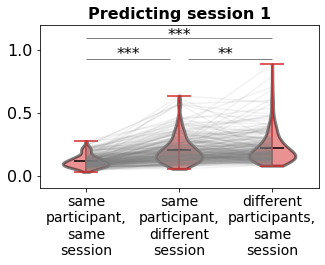

In [175]:
# plot_rmse_dist(self_rmse_ses1_t_ses2, mean_rmse_ses1_t_ses2, other_rmse_ses1_t_ses2, 'ses 1 to ses 2')
ylims = 0,16
title = 'Predicting session 1'# es1_to_ses2_all4
ylabel = ''#'Error in predicting ses1'
flname = f'{rootfile_results}/predicting_session1'
plot_rmse_dist_4_plots(self_fit_ses1['RMSE'], cross_fit_ses2to1['RMSE'], self_fit_mean_ses1['RMSE'], flname, title,ylabel,ylims)

0. param1:self_sameses,param2:self_altses,MD:-0.13,t=-6.06 (p < .001)
1. param1:self_sameses,param2:mean_sameses,MD:-0.21,t=-3.40 (p < .001)
2. param1:self_altses,param2:mean_sameses,MD:-0.08,t=-1.86 (p=0.06)
Self v mean:


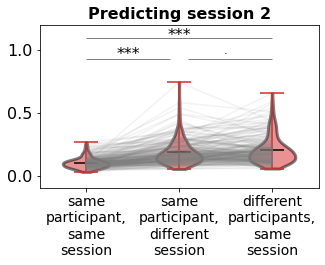

In [176]:
# plot_rmse_dist(self_rmse_ses1_t_ses2, mean_rmse_ses1_t_ses2, other_rmse_ses1_t_ses2, 'ses 1 to ses 2')
ylims = 0,16
title = 'Predicting session 2'# es1_to_ses2_all4
flname = f'{rootfile_results}/Predicting_session2'
ylabel = ''#'Error in predicting ses2'
# plot_rmse_dist_4_plots(self_fit_ses1['RMSE'], cross_fit_ses2to1['RMSE'], self_fit_mean_ses1['RMSE'], cross_fit_mean_ses2_to_ses1['RMSE'], flname, title)
plot_rmse_dist_4_plots(self_fit_ses2['RMSE'], cross_fit_ses1to2['RMSE'], self_fit_mean_ses2['RMSE'], flname, title,ylabel,ylims)